# The feature table

What the model actually reads. One row per club per match, and every number in a
row is knowable before that match kicked off.

Built by `scripts/build_dataset.py`. For the ratings that feed it, see
`plea_ratings.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plfootball import config

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 250)

table = pd.read_parquet(config.PROCESSED / "features.parquet")

print(f"{len(table):,} rows x {len(table.columns)} columns")
print(f"seasons {table['season'].min()} to {table['season'].max()}  "
      f"({table['season'].nunique()} of them)")
table.head(6)

12,160 rows x 35 columns
seasons 2011 to 2026  (16 of them)


,date,season,team,opponent,matchweek,is_home,day_of_week,rest_days,opp_rest_days,rest_days_gap,crowd,own_elo,opp_elo,elo_gap,elo_expected,form_gf,form_ga,form_shots,form_sot,form_corners,form_points,opp_form_gf,opp_form_ga,opp_form_shots,opp_form_sot,opp_form_corners,opp_form_points,form_accuracy,form_finishing,opp_form_accuracy,opp_form_finishing,played,ppg,position,target
0,2010-08-14,2011,Aston Villa,West Ham United,1,1,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.592466,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,1
1,2010-08-14,2011,Birmingham City,Sunderland,1,0,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.407534,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,0
2,2010-08-14,2011,Blackburn Rovers,Everton,1,1,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.592466,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,1
3,2010-08-14,2011,Blackpool,Wigan Athletic,1,0,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.407534,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,1
4,2010-08-14,2011,Bolton Wanderers,Fulham,1,1,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.592466,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,0
5,2010-08-14,2011,Chelsea,West Bromwich Albion,1,1,5,14.0,14.0,0.0,1,1500.0,1500.0,0.0,0.592466,1.4,1.4,12.74,4.89,5.3,0.5,1.4,1.4,12.74,4.89,5.3,0.5,0.38383,0.286299,0.38383,0.286299,0,1.07,15,1


---
# A full matchweek

Every column, every club, for one round of fixtures: matchweek 20 of 2025/26,
played over 3 and 4 January. Ten matches, so twenty rows.

This is exactly what the model sees. Nothing in these rows comes from the match
being played; it is all history as it stood that morning.

In [2]:
SEASON, MATCHWEEK = 2026, 20

week = (
    table[(table["season"] == SEASON) & (table["matchweek"] == MATCHWEEK)]
    .sort_values(["date", "team"])
    .reset_index(drop=True)
)

print(f"{len(week)} rows, {week['team'].nunique()} clubs, "
      f"{week['date'].min():%d %b} to {week['date'].max():%d %b %Y}")
week.round(2)

20 rows, 20 clubs, 03 Jan to 04 Jan 2026


C:\Users\Mani\AppData\Local\Temp\ipykernel_2544\2569160638.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  week.round(2)


,date,season,team,opponent,matchweek,is_home,day_of_week,rest_days,opp_rest_days,rest_days_gap,crowd,own_elo,opp_elo,elo_gap,elo_expected,form_gf,form_ga,form_shots,form_sot,form_corners,form_points,opp_form_gf,opp_form_ga,opp_form_shots,opp_form_sot,opp_form_corners,opp_form_points,form_accuracy,form_finishing,opp_form_accuracy,opp_form_finishing,played,ppg,position,target
0,2026-01-03,2026,Arsenal,Bournemouth,20,0,5,4.0,4.0,0.0,1,1720.63,1501.59,219.03,0.71,2.0,1.0,18.0,5.2,4.8,0.8,1.6,2.2,16.0,6.2,6.4,0.4,0.29,0.38,0.39,0.26,19,2.28,1,1
1,2026-01-03,2026,Aston Villa,Nottingham Forest,20,1,5,4.0,4.0,0.0,1,1626.70,1462.28,164.42,0.79,2.0,1.8,11.2,5.0,4.2,0.8,0.8,1.6,12.4,3.8,5.0,0.2,0.45,0.40,0.31,0.21,19,1.99,3,1
2,2026-01-03,2026,Bournemouth,Arsenal,20,1,5,4.0,4.0,0.0,1,1501.59,1720.63,-219.03,0.29,1.6,2.2,16.0,6.2,6.4,0.4,2.0,1.0,18.0,5.2,4.8,0.8,0.39,0.26,0.29,0.38,19,1.27,15,0
3,2026-01-03,2026,Brighton and Hove Albion,Burnley,20,1,5,4.0,4.0,0.0,1,1539.79,1357.31,182.48,0.81,0.8,1.4,15.2,3.6,4.4,0.3,1.0,1.8,12.0,3.2,6.2,0.2,0.24,0.22,0.27,0.31,19,1.38,14,1
4,2026-01-03,2026,Burnley,Brighton and Hove Albion,20,0,5,4.0,4.0,0.0,1,1357.31,1539.79,-182.48,0.19,1.0,1.8,12.0,3.2,6.2,0.2,0.8,1.4,15.2,3.6,4.4,0.3,0.27,0.31,0.24,0.22,19,0.72,19,0
5,2026-01-03,2026,Nottingham Forest,Aston Villa,20,0,5,4.0,4.0,0.0,1,1462.28,1626.70,-164.42,0.21,0.8,1.6,12.4,3.8,5.0,0.2,2.0,1.8,11.2,5.0,4.2,0.8,0.31,0.21,0.45,0.40,19,1.11,17,0
6,2026-01-03,2026,West Ham United,Wolverhampton Wanderers,20,0,5,4.0,4.0,0.0,1,1417.43,1334.06,83.37,0.53,1.0,2.0,10.4,3.4,4.2,0.2,0.8,2.2,8.0,2.8,2.4,0.1,0.33,0.29,0.35,0.29,19,0.82,18,0
7,2026-01-03,2026,Wolverhampton Wanderers,West Ham United,20,1,5,4.0,4.0,0.0,1,1334.06,1417.43,-83.37,0.47,0.8,2.2,8.0,2.8,2.4,0.1,1.0,2.0,10.4,3.4,4.2,0.2,0.35,0.29,0.33,0.29,19,0.36,20,1
8,2026-01-04,2026,Brentford,Everton,20,0,6,3.0,5.0,-2.0,1,1529.91,1526.28,3.63,0.41,1.4,0.8,8.0,3.6,3.0,0.6,1.0,0.6,10.6,3.4,4.4,0.5,0.45,0.39,0.32,0.29,19,1.43,10,1
9,2026-01-04,2026,Chelsea,Manchester City,20,0,6,5.0,3.0,2.0,1,1583.73,1702.23,-118.50,0.26,1.4,1.2,14.4,3.8,5.2,0.5,2.2,0.2,14.4,5.8,4.8,0.9,0.26,0.37,0.40,0.38,19,1.63,5,0


Thirty-five columns is a lot to read across. Same twenty rows, broken into the
groups they belong to.

### Who is playing whom

In [3]:
week[["date", "team", "opponent", "is_home", "day_of_week",
      "rest_days", "opp_rest_days", "rest_days_gap", "crowd"]]

,date,team,opponent,is_home,day_of_week,rest_days,opp_rest_days,rest_days_gap,crowd
0,2026-01-03,Arsenal,Bournemouth,0,5,4.0,4.0,0.0,1
1,2026-01-03,Aston Villa,Nottingham Forest,1,5,4.0,4.0,0.0,1
2,2026-01-03,Bournemouth,Arsenal,1,5,4.0,4.0,0.0,1
3,2026-01-03,Brighton and Hove Albion,Burnley,1,5,4.0,4.0,0.0,1
4,2026-01-03,Burnley,Brighton and Hove Albion,0,5,4.0,4.0,0.0,1
5,2026-01-03,Nottingham Forest,Aston Villa,0,5,4.0,4.0,0.0,1
6,2026-01-03,West Ham United,Wolverhampton Wanderers,0,5,4.0,4.0,0.0,1
7,2026-01-03,Wolverhampton Wanderers,West Ham United,1,5,4.0,4.0,0.0,1
8,2026-01-04,Brentford,Everton,0,6,3.0,5.0,-2.0,1
9,2026-01-04,Chelsea,Manchester City,0,6,5.0,3.0,2.0,1


### What PLEA makes of it

`elo_expected` is PLEA's own answer before the model gets involved: the share of
the points this club should take. The two rows of a match sum to 1.

In [4]:
week[["team", "opponent", "is_home", "own_elo", "opp_elo", "elo_gap",
      "elo_expected"]].round({"own_elo": 0, "opp_elo": 0, "elo_gap": 0,
                             "elo_expected": 3})

,team,opponent,is_home,own_elo,opp_elo,elo_gap,elo_expected
0,Arsenal,Bournemouth,0,1721.0,1502.0,219.0,0.708
1,Aston Villa,Nottingham Forest,1,1627.0,1462.0,164.0,0.789
2,Bournemouth,Arsenal,1,1502.0,1721.0,-219.0,0.292
3,Brighton and Hove Albion,Burnley,1,1540.0,1357.0,182.0,0.806
4,Burnley,Brighton and Hove Albion,0,1357.0,1540.0,-182.0,0.194
5,Nottingham Forest,Aston Villa,0,1462.0,1627.0,-164.0,0.211
6,West Ham United,Wolverhampton Wanderers,0,1417.0,1334.0,83.0,0.526
7,Wolverhampton Wanderers,West Ham United,1,1334.0,1417.0,-83.0,0.474
8,Brentford,Everton,0,1530.0,1526.0,4.0,0.413
9,Chelsea,Manchester City,0,1584.0,1702.0,-119.0,0.258


### Recent form, this club's last five matches

In [5]:
week[["team", "form_gf", "form_ga", "form_shots", "form_sot", "form_corners",
      "form_points", "form_accuracy", "form_finishing"]].round(2)

,team,form_gf,form_ga,form_shots,form_sot,form_corners,form_points,form_accuracy,form_finishing
0,Arsenal,2.0,1.0,18.0,5.2,4.8,0.8,0.29,0.38
1,Aston Villa,2.0,1.8,11.2,5.0,4.2,0.8,0.45,0.40
2,Bournemouth,1.6,2.2,16.0,6.2,6.4,0.4,0.39,0.26
3,Brighton and Hove Albion,0.8,1.4,15.2,3.6,4.4,0.3,0.24,0.22
4,Burnley,1.0,1.8,12.0,3.2,6.2,0.2,0.27,0.31
5,Nottingham Forest,0.8,1.6,12.4,3.8,5.0,0.2,0.31,0.21
6,West Ham United,1.0,2.0,10.4,3.4,4.2,0.2,0.33,0.29
7,Wolverhampton Wanderers,0.8,2.2,8.0,2.8,2.4,0.1,0.35,0.29
8,Brentford,1.4,0.8,8.0,3.6,3.0,0.6,0.45,0.39
9,Chelsea,1.4,1.2,14.4,3.8,5.2,0.5,0.26,0.37


### Recent form, the opponent's last five

The same six numbers for whoever they are facing. A club in good form against the
league leaders is a different proposition from the same club against the bottom
side, and this is where that shows up.

In [6]:
week[["team", "opponent", "opp_form_gf", "opp_form_ga", "opp_form_shots",
      "opp_form_sot", "opp_form_corners", "opp_form_points",
      "opp_form_accuracy", "opp_form_finishing"]].round(2)

,team,opponent,opp_form_gf,opp_form_ga,opp_form_shots,opp_form_sot,opp_form_corners,opp_form_points,opp_form_accuracy,opp_form_finishing
0,Arsenal,Bournemouth,1.6,2.2,16.0,6.2,6.4,0.4,0.39,0.26
1,Aston Villa,Nottingham Forest,0.8,1.6,12.4,3.8,5.0,0.2,0.31,0.21
2,Bournemouth,Arsenal,2.0,1.0,18.0,5.2,4.8,0.8,0.29,0.38
3,Brighton and Hove Albion,Burnley,1.0,1.8,12.0,3.2,6.2,0.2,0.27,0.31
4,Burnley,Brighton and Hove Albion,0.8,1.4,15.2,3.6,4.4,0.3,0.24,0.22
5,Nottingham Forest,Aston Villa,2.0,1.8,11.2,5.0,4.2,0.8,0.45,0.40
6,West Ham United,Wolverhampton Wanderers,0.8,2.2,8.0,2.8,2.4,0.1,0.35,0.29
7,Wolverhampton Wanderers,West Ham United,1.0,2.0,10.4,3.4,4.2,0.2,0.33,0.29
8,Brentford,Everton,1.0,0.6,10.6,3.4,4.4,0.5,0.32,0.29
9,Chelsea,Manchester City,2.2,0.2,14.4,5.8,4.8,0.9,0.40,0.38


### The season so far, and the answer

`target` is the only column here that comes from the match itself. It is what the
model is learning to predict.

In [7]:
week[["team", "opponent", "is_home", "played", "ppg", "position",
      "target"]].round({"ppg": 2})

,team,opponent,is_home,played,ppg,position,target
0,Arsenal,Bournemouth,0,19,2.28,1,1
1,Aston Villa,Nottingham Forest,1,19,1.99,3,1
2,Bournemouth,Arsenal,1,19,1.27,15,0
3,Brighton and Hove Albion,Burnley,1,19,1.38,14,1
4,Burnley,Brighton and Hove Albion,0,19,0.72,19,0
5,Nottingham Forest,Aston Villa,0,19,1.11,17,0
6,West Ham United,Wolverhampton Wanderers,0,19,0.82,18,0
7,Wolverhampton Wanderers,West Ham United,1,19,0.36,20,1
8,Brentford,Everton,0,19,1.43,10,1
9,Chelsea,Manchester City,0,19,1.63,5,0


---
## One match, both perspectives

Pulling a single fixture out of that week. Every match becomes two mirrored rows;
the model scores each separately and the two answers are then merged into one
call.

In [8]:
pair = week[week["team"].isin(["Arsenal", "Bournemouth"])]

pair[["date", "team", "opponent", "is_home", "own_elo", "opp_elo", "elo_gap",
      "elo_expected", "form_gf", "form_points", "ppg", "position",
      "target"]].round(3).T

C:\Users\Mani\AppData\Local\Temp\ipykernel_2544\3243882405.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "target"]].round(3).T


,0,2
date,2026-01-03 00:00:00,2026-01-03 00:00:00
team,Arsenal,Bournemouth
opponent,Bournemouth,Arsenal
is_home,0,1
own_elo,1720.626,1501.592
opp_elo,1501.592,1720.626
elo_gap,219.035,-219.035
elo_expected,0.708,0.292
form_gf,2.0,1.6
form_points,0.8,0.4


---
## Cold starts

There are no blanks left in the table. Where a club has no history to go on, its
first match ever or the first match of a season, the value is a prior rather than
a gap. The README has the full policy.

In [9]:
print("blank cells anywhere in the table:",
      int(table.isna().sum().sum()))
print("infinities:",
      int(np.isinf(table.select_dtypes("number")).sum().sum()))

blank cells anywhere in the table: 0
infinities: 0


### Where the priors land

Every club's opening match of 2025/26. `ppg` and `position` here are last
season's final numbers, except for clubs that were not in the division last year,
which take the promoted priors of 1.07 and 15th.

In [10]:
opening = (
    table[(table["season"] == 2026) & (table["matchweek"] == 1)]
    .sort_values("ppg", ascending=False)
    .copy()
)

opening["prior"] = np.where(
    (opening["ppg"] == config.PROMOTED_PPG)
    & (opening["position"] == config.PROMOTED_POSITION),
    "promoted",
    "last season",
)

opening[["team", "opponent", "is_home", "own_elo", "ppg", "position",
         "rest_days", "prior"]].round({"own_elo": 0, "ppg": 2})

,team,opponent,is_home,own_elo,ppg,position,rest_days,prior
11401,Liverpool,Bournemouth,1,1673.0,2.21,1,14.0,last season
11412,Arsenal,Manchester United,0,1660.0,1.95,2,14.0,last season
11406,Manchester City,Wolverhampton Wanderers,0,1658.0,1.87,3,14.0,last season
11414,Chelsea,Crystal Palace,1,1585.0,1.82,4,14.0,last season
11402,Aston Villa,Newcastle United,1,1572.0,1.74,6,14.0,last season
11407,Newcastle United,Aston Villa,0,1573.0,1.74,5,14.0,last season
11417,Nottingham Forest,Brentford,1,1528.0,1.71,7,14.0,last season
11403,Brighton and Hove Albion,Fulham,1,1547.0,1.61,8,14.0,last season
11400,Bournemouth,Liverpool,0,1529.0,1.47,9,14.0,last season
11413,Brentford,Nottingham Forest,0,1526.0,1.47,10,14.0,last season


### How fast the prior fades

Points per game is a blend of this season and last:

    (played x this_season + 5 x last_season) / (played + 5)

At matchweek 1 it is entirely last season. By matchweek 10 or so this season has
taken over. Below is one club's estimate settling.

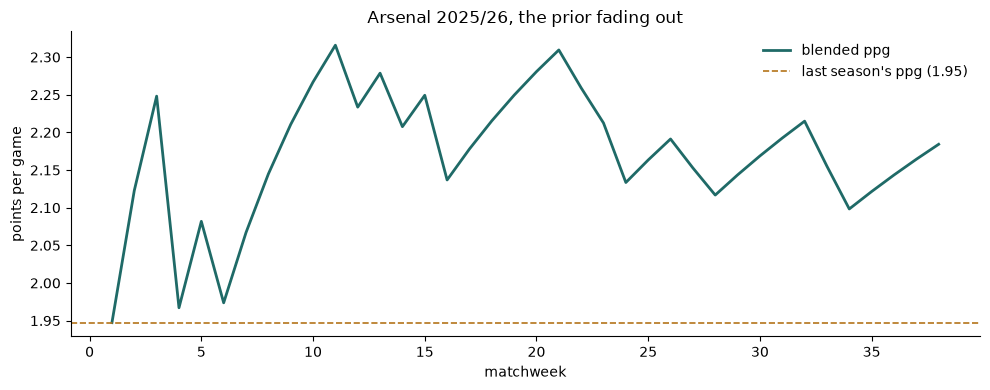

In [11]:
run_ppg = (
    table[(table["team"] == "Arsenal") & (table["season"] == 2026)]
    .sort_values("matchweek")
)
prior_value = run_ppg["ppg"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(run_ppg["matchweek"], run_ppg["ppg"], color="#1F6A67", linewidth=2,
        label="blended ppg")
ax.axhline(prior_value, color="#B4741A", linestyle="--", linewidth=1.2,
           label=f"last season's ppg ({prior_value:.2f})")
ax.set_xlabel("matchweek")
ax.set_ylabel("points per game")
ax.set_title("Arsenal 2025/26, the prior fading out")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Following one club through a season

`form_gf` at each matchweek is the average goals from the five matches before it,
never the match itself. If that column ever included the current match, the model
would look brilliant and be worthless, so it is worth being able to see the gap
by eye.

In [12]:
run = (
    table[(table["team"] == "Arsenal") & (table["season"] == 2026)]
    .sort_values("date")
)

run[["matchweek", "date", "opponent", "is_home", "own_elo", "form_gf",
     "form_points", "ppg", "position", "target"]].head(12).round(
    {"own_elo": 0, "form_gf": 2, "form_points": 2, "ppg": 2})

,matchweek,date,opponent,is_home,own_elo,form_gf,form_points,ppg,position,target
11412,1,2025-08-17,Manchester United,0,1660.0,1.6,0.6,1.95,2,1
11422,2,2025-08-23,Leeds United,1,1666.0,1.4,0.7,2.12,7,1
11452,3,2025-08-31,Liverpool,0,1672.0,2.2,0.9,2.25,2,0
11460,4,2025-09-13,Nottingham Forest,1,1664.0,1.8,0.8,1.97,3,1
11494,5,2025-09-21,Manchester City,1,1672.0,2.2,0.8,2.08,3,0
11514,6,2025-09-28,Newcastle United,0,1669.0,2.0,0.7,1.97,7,1
11522,7,2025-10-04,West Ham United,1,1678.0,2.2,0.7,2.07,3,1
11540,8,2025-10-18,Fulham,0,1683.0,1.6,0.7,2.14,1,1
11570,9,2025-10-26,Crystal Palace,1,1689.0,1.8,0.9,2.21,1,1
11580,10,2025-11-01,Burnley,0,1694.0,1.4,0.9,2.27,1,1


## Which columns look related to winning

A first glance only. These are one-at-a-time correlations, which hide the
interactions the model actually learns; the real answer comes from the trained
model. Mostly this lives here as a tripwire: anything above 0.70 would mean a
column has seen the result it is meant to be predicting.

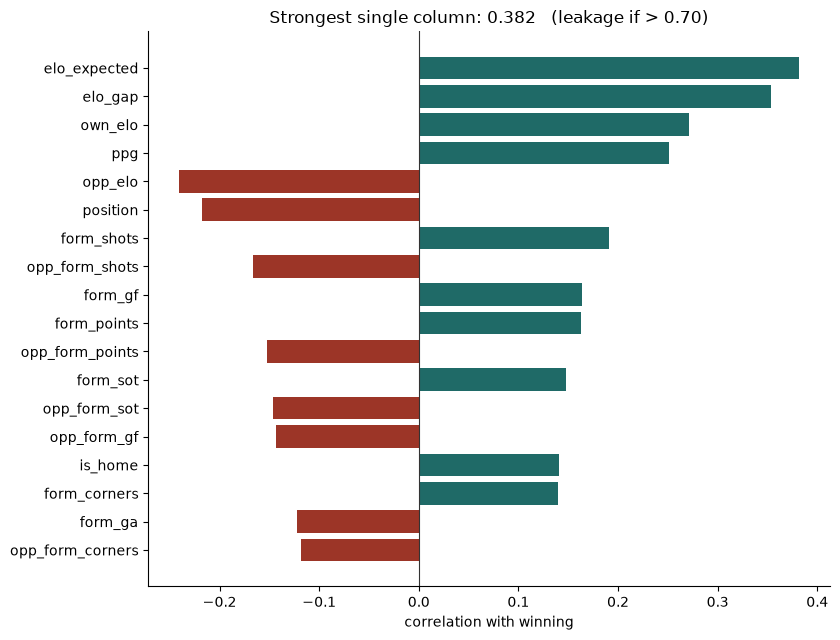

In [13]:
ignore = {"date", "season", "team", "opponent", "target"}
numeric = table[[c for c in table.columns if c not in ignore]].select_dtypes("number")
corr = numeric.corrwith(table["target"]).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
top = corr.head(18)[::-1]
ax.barh(top.index, top.values,
        color=["#1F6A67" if v > 0 else "#9C3527" for v in top.values])
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("correlation with winning")
ax.set_title(f"Strongest single column: {corr.abs().max():.3f}   (leakage if > 0.70)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()